# 027 — Name correlation-based feature clusters

Assigns a human-readable name and representative feature to every cluster produced by the
hierarchical correlation clustering in notebook 021.

**Input files** (from `results/{expt}/features/clustering/`):
- `feature_clusters_at_distances.csv` — feature → cluster ID at each distance threshold
- `feature_correlation_matrix.csv` — pairwise Spearman correlations
- `optimal_threshold.txt` — saved optimal distance threshold

**Input SHAP importance** (from `results/{expt}/features/shap_testing/`):
- `shap_aggregated.csv` — mean |SHAP| across CV folds

**Output** (written to `results/{expt}/features/clustering/`):
- `cluster_names.csv` — one row per cluster: `cluster_id`, `name`, `category`, `representative_feature`, `n_members`, `top_shap`

## 0. Imports

In [ ]:
import sys
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# ── font setup ───────────────────────────────────────────────────────────────
font_dir = Path("/mnt/cbib/LNClassifier/msfonts")
if font_dir.exists():
    for fp in font_dir.glob("*.ttf"):
        fm.fontManager.addfont(str(fp))
    plt.rcParams["font.family"] = "Arial"
plt.rcParams["figure.dpi"] = 300

# ── workflow utils ────────────────────────────────────────────────────────────
sys.path.insert(0, "/mnt/cbib/LNClassifier/paper/workflow")
from utils.feature_analysis import cluster_features

np.random.seed(42)
print("✓ Imports OK")

✓ Imports OK


## 1. Configuration

In [ ]:
DATASET_NAME = "gencode.v47.common.cdhit.cv"
BASEDIR      = Path("/mnt/cbib/LNClassifier/paper")

CLUSTER_DIR  = BASEDIR / f"results/{DATASET_NAME}/features/clustering"
SHAP_PATH    = BASEDIR / f"results/{DATASET_NAME}/features/shap_clustered/shap_aggregated.csv"
OUTPUT_PATH  = CLUSTER_DIR / "cluster_names.csv"

# Read the saved optimal threshold (fall back to 0.25 if file is missing)
_thresh_file = CLUSTER_DIR / "optimal_threshold.txt"
DISTANCE_THRESHOLD: float = (
    float(_thresh_file.read_text().strip()) if _thresh_file.exists() else 0.25
)

print(f"Dataset       : {DATASET_NAME}")
print(f"Cluster dir   : {CLUSTER_DIR}")
print(f"SHAP path     : {SHAP_PATH}")
print(f"Distance thr  : {DISTANCE_THRESHOLD}")
print(f"Output        : {OUTPUT_PATH}")

Dataset       : gencode.v47.common.cdhit.cv
Cluster dir   : /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/clustering
SHAP path     : /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/shap_aggregated.csv
Distance thr  : 0.25
Output        : /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/clustering/cluster_names.csv


## 2. Data loading

In [ ]:
# ── Cluster assignments at every saved threshold ─────────────────────────────
clusters_all = pd.read_csv(CLUSTER_DIR / "feature_clusters_at_distances.csv", index_col=0)
print(f"✓ Cluster table  : {clusters_all.shape[0]} features × {clusters_all.shape[1]} thresholds")

# ── Correlation matrix ────────────────────────────────────────────────────────
corr_matrix = pd.read_csv(CLUSTER_DIR / "feature_correlation_matrix.csv", index_col=0)
print(f"✓ Correlation    : {corr_matrix.shape[0]}×{corr_matrix.shape[1]}")

# ── SHAP importance ───────────────────────────────────────────────────────────
shap_df = pd.read_csv(SHAP_PATH, index_col=0) if SHAP_PATH.exists() else None
if shap_df is not None:
    print(f"✓ SHAP           : {shap_df.shape[0]} features")
else:
    print("⚠  SHAP file not found — cluster representatives will fall back to first member")

✓ Cluster table  : 439 features × 29 thresholds
✓ Correlation    : 439×439
✓ SHAP           : 179 features


## 3. Feature-category rules

Each feature name encodes its origin tool and biological meaning.
The table below maps suffix / prefix patterns to a short biological category used later
for auto-naming clusters.

In [ ]:
# Rules applied in order; first match wins.
# Each rule is (regex_pattern, category_label).
CATEGORY_RULES: list[tuple[str, str]] = [
    # ── Presence / indicator flags (checked before prefix rules) ─────────────
    (r"_present$",                                 "Non-B DNA presence flag"),
    # ── Tool-specific ORF / coding potential features ────────────────────────
    (r"ORF.*_(cpat|lncDC|feelnc|lncfinder)$",     "ORF / coding potential"),
    (r"^orf", "ORF / coding potential"),
    (r"Hexamer.*_(cpat|lncDC)$",                   "Hexamer score"),
    (r"Fickett.*(cpat|lncDC|lncfinder)$",          "Fickett score"),
    (r"\.dist|\.Dist|_Dist|UP\.PCT|SNR",                 "Sequence composition ratio"),
    (r"kmerScore.*feelnc$",                        "k-mer score (FEELnc)"),
    (r"RNA_size_feelnc$",                          "Transcript length"),
    (r"^RCB_", "Codon bias"),
    (r"^SS_score", "SS_score (lncDC)"),
    (r"^Signal", "FFT Power Signal (LncFinder)"),
    (r"^MFE", "MFE"),
    # ── k-mer composition (PLncPRO 3-mers) ──────────────────────────────────
    (r"^[ACGT]{3}_plncpro$",                       "3-mer composition (PLncPRO)"),
    # –– GC content
    (r"^GC_", "GC content"),
    # –– Conservation
    (r"(Frame_Entropy|numhits|Bitscore|HitScore)", "BLAST conservation"),
    # ── TE / repeat pipeline ─────────────────────────────────────────────────
    (r"^te_",                                      "TE content"),
    (r"^lctr_",                                    "Low-complexity / satellite repeat"),
    (r"^pseudo",                                  "Pseudogene / retrotransposon remnant"),
    (r"^unknown_",                                 "Unknown repeat"),
    (r"^global_",                                  "Global repeat landscape"),
    # ── Non-B DNA motifs ─────────────────────────────────────────────────────
    (r"^(apr|dr|gq|ir|mr|str|tri|z)_",            "Non-B DNA motif"),
    (r"^(any_nonb|all_nonb|motif_|total_nonb|n_motif_types)",               "Non-B DNA motif (summary)"),
]

def infer_category(feature_name: str) -> str:
    """Return the first matching biological category for a feature name."""
    for pattern, label in CATEGORY_RULES:
        if re.search(pattern, feature_name):
            return label
    return "Other"

# Quick sanity-check
_examples = [
    ("kmerScore_12mer_feelnc", "k-mer score (FEELnc)"),
    ("ORF.Max.Len_lncfinder",  "ORF / coding potential"),
    ("AAA_plncpro",             "3-mer composition (PLncPRO)"),
    ("te_count",                "TE content"),
    ("gq_hit_count",            "Non-B DNA motif"),
    ("gq_present",              "Non-B DNA presence flag"),
    ("any_nonb_present",        "Non-B DNA presence flag"),
    ("Fickett_l_cpat",          "Fickett score"),
    ("pseudo_count",            "Pseudogene / retrotransposon remnant"),
    ("motif_diversity",         "Non-B DNA motif (summary)"),
]
_ok = all(infer_category(feat) == expected for feat, expected in _examples)
assert _ok, "Category rule self-test failed:\n" + "\n".join(
    f"  {feat!r}: expected={expected!r}, got={infer_category(feat)!r}"
    for feat, expected in _examples
    if infer_category(feat) != expected
)
print("✓ Category rules OK")

✓ Category rules OK


## 4. Build cluster membership at chosen threshold

In [ ]:
# Pick the column matching the desired threshold
_col = f"cluster_{DISTANCE_THRESHOLD:.2f}"
if _col not in clusters_all.columns:
    # Fall back to the closest available threshold
    _available = [float(c.split("_")[1]) for c in clusters_all.columns]
    _best = min(_available, key=lambda x: abs(x - DISTANCE_THRESHOLD))
    _col = f"cluster_{_best:.2f}"
    print(f"⚠  Exact threshold {DISTANCE_THRESHOLD} not found; using {_best}")

membership = clusters_all[[_col]].rename(columns={_col: "cluster_id"}).copy()
membership.index.name = "feature"

# Assign categories
membership["category"] = membership.index.map(infer_category)

# Add SHAP importance when available
if shap_df is not None:
    membership = membership.join(shap_df[["mean_abs_shap"]], how="left")
else:
    membership["mean_abs_shap"] = np.nan

print(f"✓ {membership['cluster_id'].nunique()} clusters at threshold {_col}")
membership

✓ 155 clusters at threshold cluster_0.25


,cluster_id,category,mean_abs_shap
feature,,,
AAA_plncpro,67,3-mer composition (PLncPRO),0.001210
AAC_plncpro,48,3-mer composition (PLncPRO),0.000602
AAG_plncpro,46,3-mer composition (PLncPRO),0.000684
AAT_plncpro,67,3-mer composition (PLncPRO),NaN
ACA_plncpro,50,3-mer composition (PLncPRO),0.001223
...,...,...,...
z_std_length_pct,124,Non-B DNA motif,NaN
z_total_length,125,Non-B DNA motif,NaN
z_total_length_pct,125,Non-B DNA motif,NaN


In [ ]:
membership[membership["category"] == "Other"]

,cluster_id,category,mean_abs_shap
feature,,,


## 5. Name each cluster

For every cluster we derive:
- **`representative_feature`** — member with the highest mean |SHAP| (ties broken by first occurrence)
- **`category`** — majority biological category among all cluster members
- **`name`** — `"{category} ({representative_feature})"` — a concise, auto-generated label

In [ ]:
def _majority_category(series: pd.Series) -> str:
    """Return the most frequent value; ties broken alphabetically."""
    counts = Counter(series)
    return max(counts, key=lambda k: (counts[k], k))


def _top_shap_feature(df_group: pd.DataFrame) -> str:
    """Return the member with the highest mean |SHAP|; fall back to first row."""
    if df_group["mean_abs_shap"].notna().any():
        return df_group["mean_abs_shap"].idxmax()
    return df_group.index[0]


rows: list[dict] = []
for cluster_id, group in membership.groupby("cluster_id"):
    rep_feat  = _top_shap_feature(group)
    top_shap  = group.loc[rep_feat, "mean_abs_shap"] if rep_feat in group.index else np.nan
    cat       = _majority_category(group["category"])
    n_members = len(group)
    # Collect all unique categories present in the cluster
    cats_present = sorted(group["category"].unique().tolist())
    rows.append(
        {
            "cluster_id":            cluster_id,
            "name":                  f"{cat} ({rep_feat})",
            "category":              cat,
            "representative_feature": rep_feat,
            "top_shap":              top_shap,
            "n_members":             n_members,
            "member_features":       "; ".join(group.index.tolist()),
            "categories_present":    "; ".join(cats_present),
        }
    )

cluster_names = (
    pd.DataFrame(rows)
    .set_index("cluster_id")
    .sort_values("top_shap", ascending=False)
)

print(f"✓ Named {len(cluster_names)} clusters")
cluster_names[["name", "category", "representative_feature", "top_shap", "n_members"]].head(20)

✓ Named 155 clusters


,name,category,representative_feature,top_shap,n_members
cluster_id,,,,,
87,BLAST conservation (all_Frame_Entropy_plncpro),BLAST conservation,all_Frame_Entropy_plncpro,0.087216,1
86,BLAST conservation (all_Bitscore_plncpro),BLAST conservation,all_Bitscore_plncpro,0.079371,3
32,k-mer score (FEELnc) (kmerScore_12mer_feelnc),k-mer score (FEELnc),kmerScore_12mer_feelnc,0.053143,1
90,ORF / coding potential (ORF.Max.Len_lncfinder),ORF / coding potential,ORF.Max.Len_lncfinder,0.038723,7
92,ORF / coding potential (ORF.Max.Cov_lncfinder),ORF / coding potential,ORF.Max.Cov_lncfinder,0.028942,4
30,k-mer score (FEELnc) (Hexamer_l_cpat),k-mer score (FEELnc),Hexamer_l_cpat,0.028845,4
34,Sequence composition ratio (Seq.Dist.Ratio_lnc...,Sequence composition ratio,Seq.Dist.Ratio_lncfinder,0.011937,1
94,Fickett score (Fickett_score_lncDC),Fickett score,Fickett_score_lncDC,0.011321,1
91,ORF / coding potential (ORF_T1_MW_lncDC),ORF / coding potential,ORF_T1_MW_lncDC,0.011182,2


## 6. Diagnostics

### 6a. Category distribution across all features

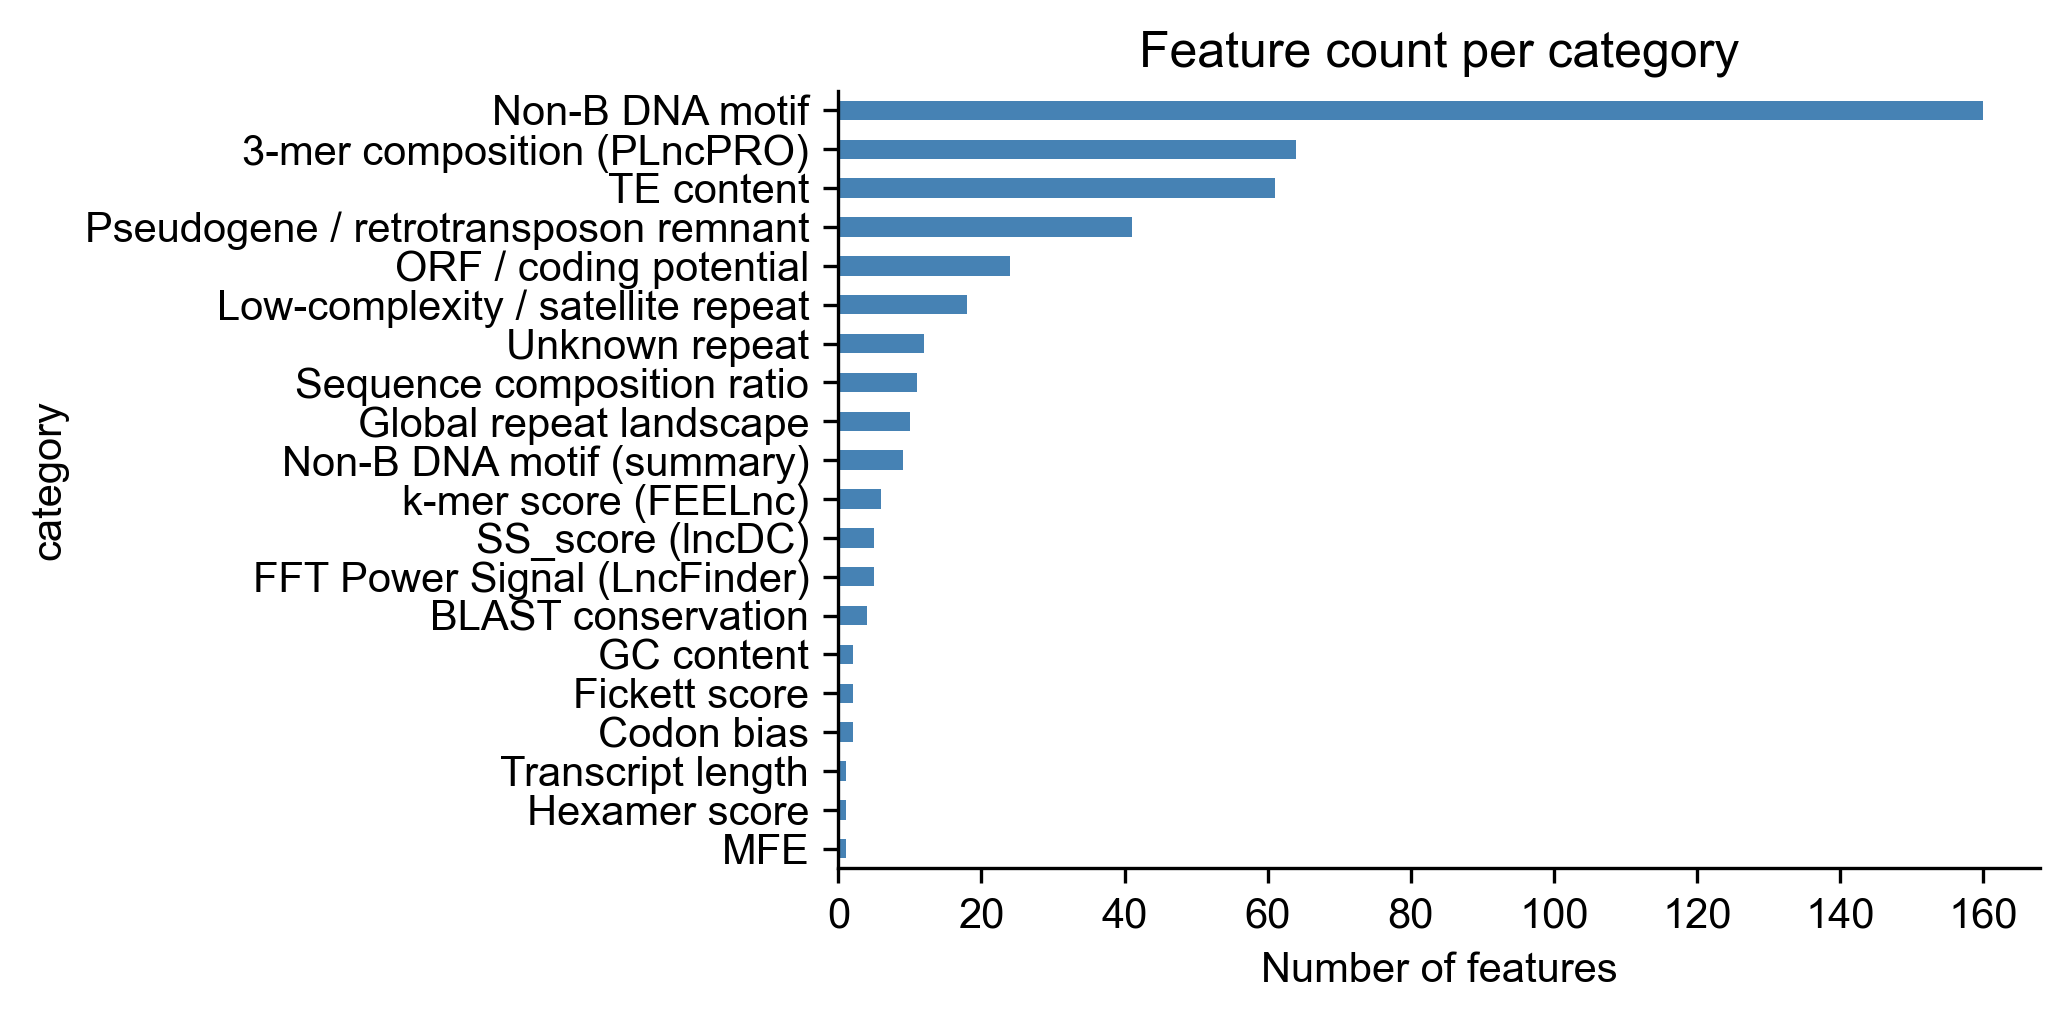

Saved → /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/clustering/cluster_category_distribution.pdf


In [ ]:
cat_counts = membership["category"].value_counts()

fig, ax = plt.subplots(figsize=(7, 3.5))
cat_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of features")
ax.set_title("Feature count per category")
ax.invert_yaxis()
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()

fig_path = CLUSTER_DIR / "cluster_category_distribution.pdf"
fig.savefig(fig_path, bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".png"), dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {fig_path}")

### 6b. Cluster size distribution

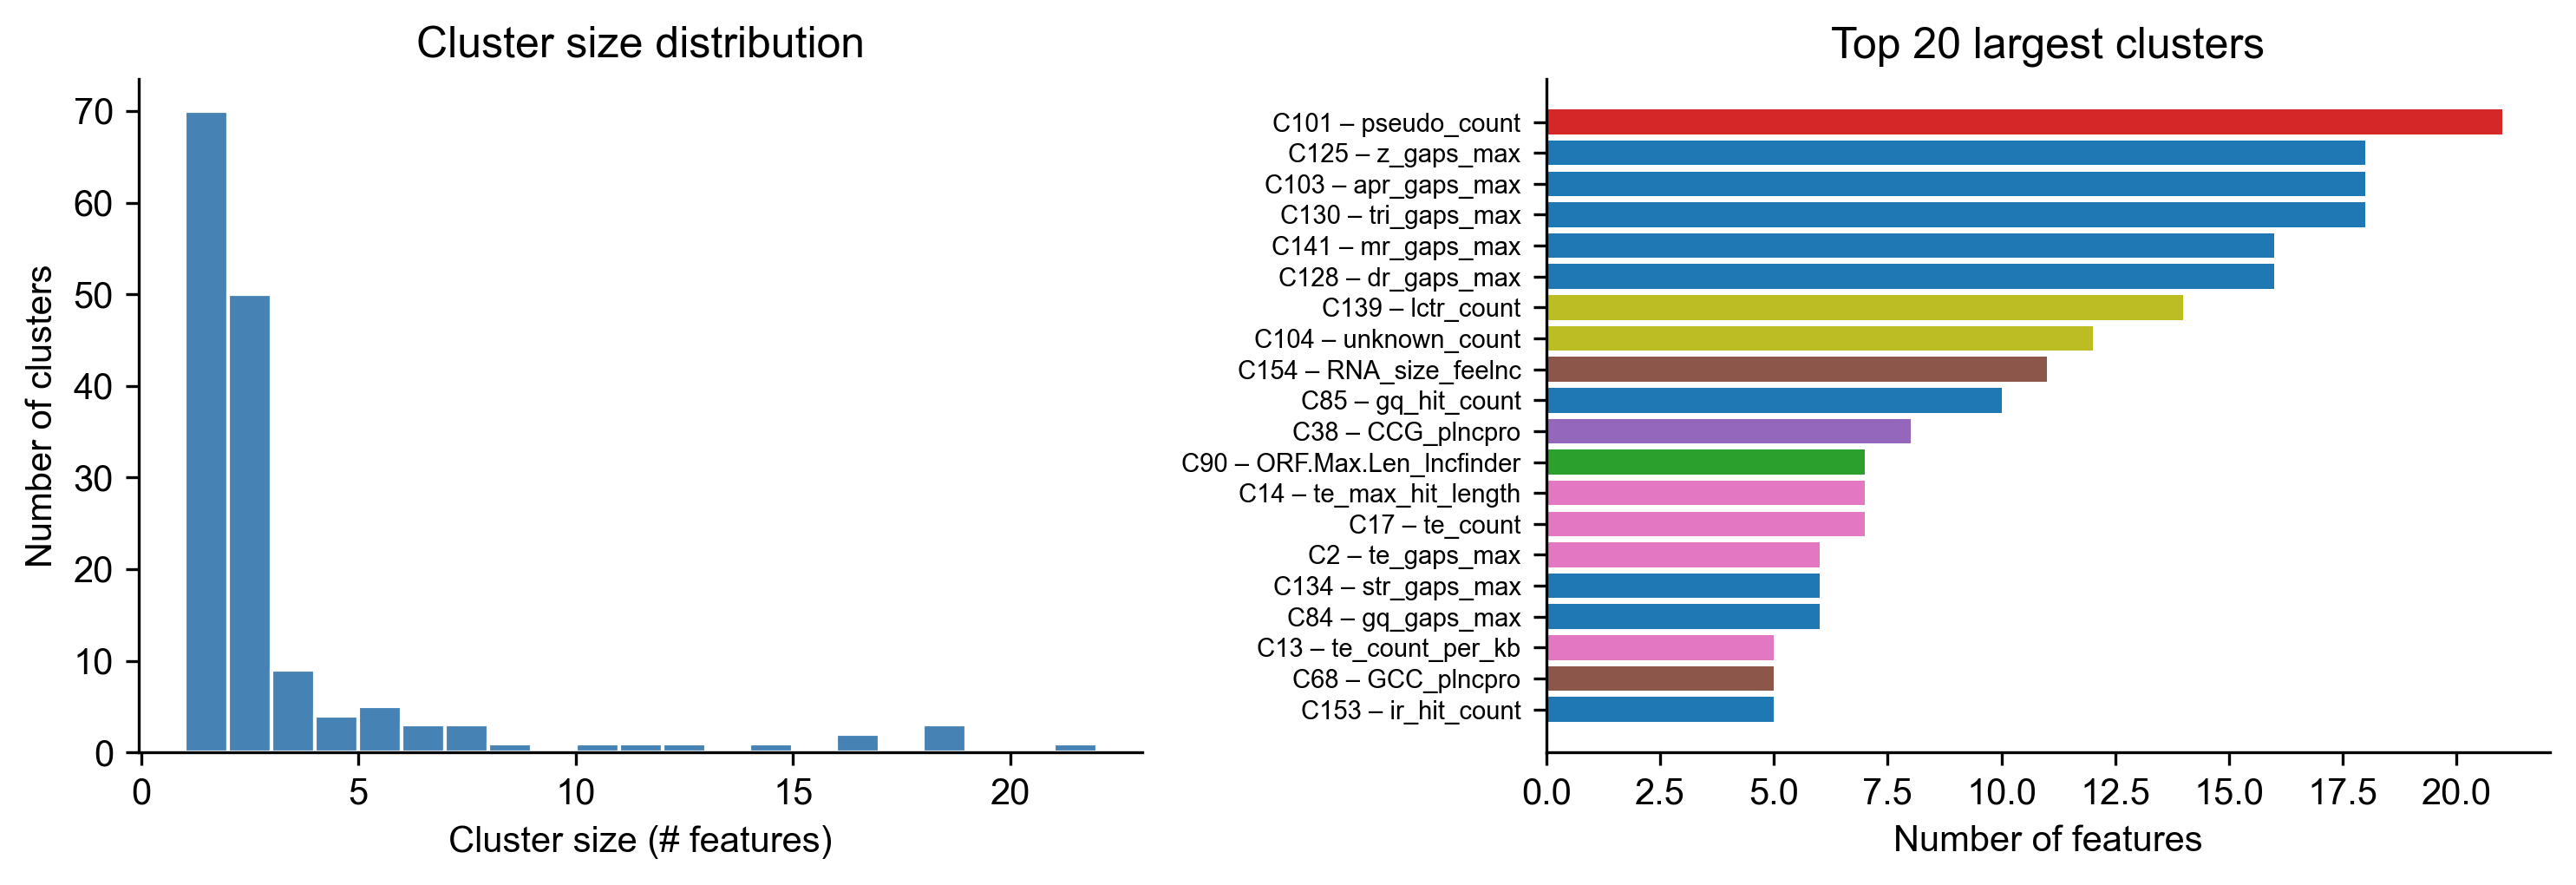

Saved → /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/clustering/cluster_size_distribution.pdf


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# Left: histogram of cluster sizes
sizes = cluster_names["n_members"]
axes[0].hist(sizes, bins=range(1, sizes.max() + 2), color="steelblue", edgecolor="white")
axes[0].set_xlabel("Cluster size (# features)")
axes[0].set_ylabel("Number of clusters")
axes[0].set_title("Cluster size distribution")
for spine in ["top", "right"]:
    axes[0].spines[spine].set_visible(False)

# Right: top 20 largest clusters coloured by dominant category
top20 = cluster_names.nlargest(20, "n_members")
palette = sns.color_palette("tab10", n_colors=membership["category"].nunique())
cat_to_color = {c: palette[i] for i, c in enumerate(sorted(membership["category"].unique()))}
colors = top20["category"].map(cat_to_color)

axes[1].barh(
    y=range(len(top20)),
    width=top20["n_members"],
    color=colors,
)
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(
    [f"C{cid} – {row['representative_feature']}" for cid, row in top20.iterrows()],
    fontsize=7,
)
axes[1].invert_yaxis()
axes[1].set_xlabel("Number of features")
axes[1].set_title("Top 20 largest clusters")
for spine in ["top", "right"]:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
fig_path = CLUSTER_DIR / "cluster_size_distribution.pdf"
fig.savefig(fig_path, bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".png"), dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {fig_path}")

### 6c. Inspect "mixed" clusters

Clusters whose members span more than one biological category may deserve a split or a more
specific name. The table below lists them ranked by number of categories present.

In [ ]:
mixed = (
    cluster_names
    .assign(n_categories=cluster_names["categories_present"].str.split("; ").str.len())
    .query("n_categories > 1")
    .sort_values(["n_categories", "n_members"], ascending=False)
)

print(f"{len(mixed)} mixed clusters (out of {len(cluster_names)} total):\n")
display_cols = [
    "name", "n_members", "n_categories", "categories_present", "representative_feature"
]
mixed[display_cols]

7 mixed clusters (out of 155 total):



,name,n_members,n_categories,categories_present,representative_feature
cluster_id,,,,,
154,Sequence composition ratio (RNA_size_feelnc),11,5,FFT Power Signal (LncFinder); MFE; ORF / codin...,RNA_size_feelnc
90,ORF / coding potential (ORF.Max.Len_lncfinder),7,3,Codon bias; ORF / coding potential; Sequence c...,ORF.Max.Len_lncfinder
68,GC content (GCC_plncpro),5,3,3-mer composition (PLncPRO); GC content; SS_sc...,GCC_plncpro
38,SS_score (lncDC) (CCG_plncpro),8,2,3-mer composition (PLncPRO); SS_score (lncDC),CCG_plncpro
153,Non-B DNA motif (ir_hit_count),5,2,Non-B DNA motif; Non-B DNA motif (summary),ir_hit_count
30,k-mer score (FEELnc) (Hexamer_l_cpat),4,2,Hexamer score; k-mer score (FEELnc),Hexamer_l_cpat
88,Sequence composition ratio (SNR_lncfinder),2,2,FFT Power Signal (LncFinder); Sequence composi...,SNR_lncfinder


### 6d. SHAP-ranked top features per cluster (top 15 clusters by SHAP)

Shows the 5 highest-SHAP members for each of the 15 most important clusters.

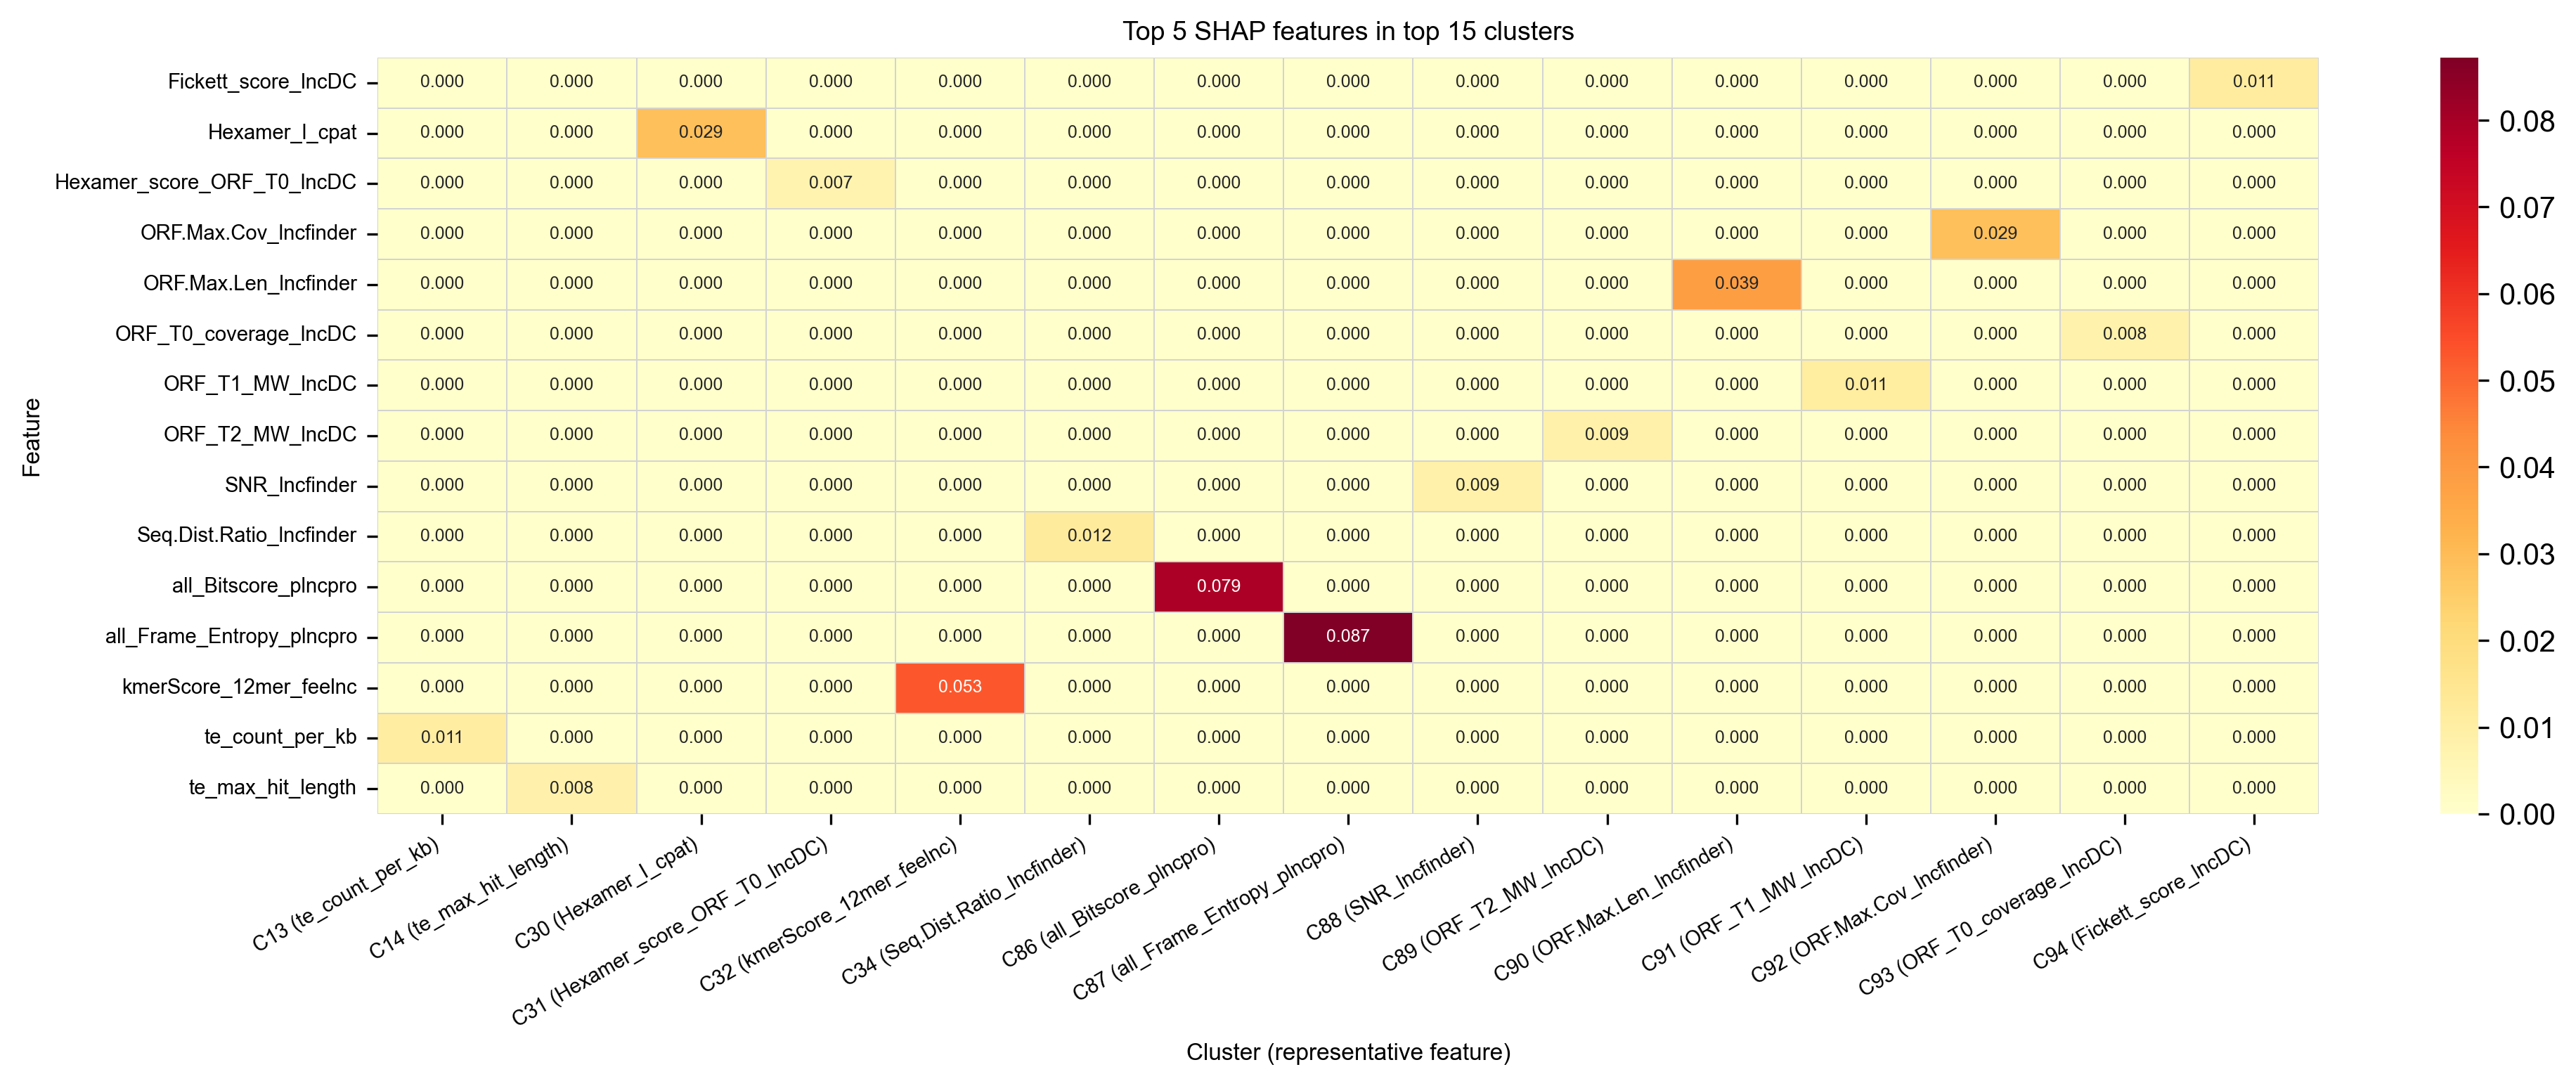

Saved → /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/clustering/cluster_shap_heatmap.pdf


In [ ]:
if shap_df is None:
    print("⚠  SHAP data not available — skipping this plot.")
else:
    TOP_N_CLUSTERS = 15
    TOP_N_FEATURES = 5

    top_cluster_ids = cluster_names.head(TOP_N_CLUSTERS).index.tolist()

    # Build a per-cluster × per-feature SHAP matrix (top N members only)
    plot_rows: list[dict] = []
    for cid in top_cluster_ids:
        members_str = cluster_names.loc[cid, "member_features"]
        members = [m for m in members_str.split("; ") if m in shap_df.index]
        if not members:
            continue
        top_feats = (
            shap_df.loc[members, "mean_abs_shap"]
            .nlargest(TOP_N_FEATURES)
        )
        for feat, val in top_feats.items():
            plot_rows.append(
                {"cluster": f"C{cid} ({cluster_names.loc[cid, 'representative_feature']})",
                 "feature": feat,
                 "mean_abs_shap": val}
            )

    plot_df = pd.DataFrame(plot_rows)
    pivot = plot_df.pivot(index="feature", columns="cluster", values="mean_abs_shap").fillna(0)

    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns) * 0.9), max(4, len(pivot) * 0.35)))
    sns.heatmap(
        pivot,
        cmap="YlOrRd",
        linewidths=0.4,
        linecolor="lightgrey",
        annot=True,
        fmt=".3f",
        annot_kws={"size": 6},
        ax=ax,
    )
    ax.set_title(f"Top {TOP_N_FEATURES} SHAP features in top {TOP_N_CLUSTERS} clusters", fontsize=9)
    ax.set_xlabel("Cluster (representative feature)", fontsize=8)
    ax.set_ylabel("Feature", fontsize=8)
    plt.xticks(rotation=30, ha="right", fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()

    fig_path = CLUSTER_DIR / "cluster_shap_heatmap.pdf"
    fig.savefig(fig_path, bbox_inches="tight")
    fig.savefig(fig_path.with_suffix(".png"), dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fig_path}")

### 6f. SHAP value sum per cluster

This only works if SHAP values were calculated on all features

In [ ]:
# 6f. SHAP value sum per cluster (ranked)

base_names = cluster_names_final if "cluster_names_final" in globals() else cluster_names

cluster_shap_rank = (
    membership.groupby("cluster_id")
    .agg(
        shap_sum=("mean_abs_shap", lambda s: s.fillna(0).sum()),
        n_members=("cluster_id", "size"),
        n_with_shap=("mean_abs_shap", lambda s: s.notna().sum()),
    )
)

cluster_shap_rank["shap_per_member"] = cluster_shap_rank["shap_sum"] / cluster_shap_rank["n_members"]
cluster_shap_rank["shap_coverage"] = cluster_shap_rank["n_with_shap"] / cluster_shap_rank["n_members"]

cluster_shap_rank = (
    cluster_shap_rank
    .join(base_names[["name", "category", "representative_feature", "top_shap"]], how="left")
    .sort_values("shap_sum", ascending=False)
)

cluster_shap_rank["rank_by_shap_sum"] = np.arange(1, len(cluster_shap_rank) + 1)

cluster_shap_rank = cluster_shap_rank[
    [
        "rank_by_shap_sum",
        "name",
        "category",
        "representative_feature",
        "shap_sum",
        "shap_per_member",
        "n_members",
        "n_with_shap",
        "shap_coverage",
        "top_shap",
    ]
]

display(cluster_shap_rank.head(20))

rank_path = CLUSTER_DIR / "cluster_shap_sum_ranking.csv"
cluster_shap_rank.to_csv(rank_path)
print(f"Saved → {rank_path}")

,rank_by_shap_sum,name,category,representative_feature,shap_sum,shap_per_member,n_members,n_with_shap,shap_coverage,top_shap
cluster_id,,,,,,,,,,
87,1,Other (all_Frame_Entropy_plncpro),Other,all_Frame_Entropy_plncpro,0.087216,0.087216,1,1,1.000000,0.087216
86,2,Other (all_Bitscore_plncpro),Other,all_Bitscore_plncpro,0.079371,0.026457,3,1,0.333333,0.079371
32,3,k-mer score (FEELnc) (kmerScore_12mer_feelnc),k-mer score (FEELnc),kmerScore_12mer_feelnc,0.053143,0.053143,1,1,1.000000,0.053143
90,4,ORF / coding potential (ORF.Max.Len_lncfinder),ORF / coding potential,ORF.Max.Len_lncfinder,0.038723,0.005532,7,1,0.142857,0.038723
92,5,ORF / coding potential (ORF.Max.Cov_lncfinder),ORF / coding potential,ORF.Max.Cov_lncfinder,0.028942,0.007235,4,1,0.250000,0.028942
30,6,k-mer score (FEELnc) (Hexamer_l_cpat),k-mer score (FEELnc),Hexamer_l_cpat,0.028845,0.007211,4,1,0.250000,0.028845
34,7,Sequence composition ratio (Seq.Dist.Ratio_lnc...,Sequence composition ratio,Seq.Dist.Ratio_lncfinder,0.011937,0.011937,1,1,1.000000,0.011937
94,8,Fickett score (Fickett_score_lncDC),Fickett score,Fickett_score_lncDC,0.011321,0.011321,1,1,1.000000,0.011321
91,9,ORF / coding potential (ORF_T1_MW_lncDC),ORF / coding potential,ORF_T1_MW_lncDC,0.011182,0.005591,2,1,0.500000,0.011182


Saved → /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/clustering/cluster_shap_sum_ranking.csv


## 7. Manual name overrides

Edit the dictionary below to replace any auto-generated name with a more specific label.
Keys are integer cluster IDs; values are the desired human-readable names.
Leave the dict empty (`{}`) to keep all auto-generated names.

In [ ]:
# ── Edit here ──────────────────────────────────────────────────────────────────
MANUAL_OVERRIDES: dict[int, str] = {
    # e.g.  1: "ORF length (high-confidence coding potential)",
    #        5: "G-quadruplex density",
}
# ───────────────────────────────────────────────────────────────────────────────

cluster_names_final = cluster_names.copy()
for cid, new_name in MANUAL_OVERRIDES.items():
    if cid in cluster_names_final.index:
        cluster_names_final.loc[cid, "name"] = new_name
    else:
        print(f"⚠  Cluster {cid} not found — skipping override.")

n_overridden = len(MANUAL_OVERRIDES)
print(f"✓ {n_overridden} manual override(s) applied.")
cluster_names_final[["name", "category", "representative_feature", "top_shap", "n_members"]].head(20)

✓ 0 manual override(s) applied.


,name,category,representative_feature,top_shap,n_members
cluster_id,,,,,
87,BLAST conservation (all_Frame_Entropy_plncpro),BLAST conservation,all_Frame_Entropy_plncpro,0.087216,1
86,BLAST conservation (all_Bitscore_plncpro),BLAST conservation,all_Bitscore_plncpro,0.079371,3
32,k-mer score (FEELnc) (kmerScore_12mer_feelnc),k-mer score (FEELnc),kmerScore_12mer_feelnc,0.053143,1
90,ORF / coding potential (ORF.Max.Len_lncfinder),ORF / coding potential,ORF.Max.Len_lncfinder,0.038723,7
92,ORF / coding potential (ORF.Max.Cov_lncfinder),ORF / coding potential,ORF.Max.Cov_lncfinder,0.028942,4
30,k-mer score (FEELnc) (Hexamer_l_cpat),k-mer score (FEELnc),Hexamer_l_cpat,0.028845,4
34,Sequence composition ratio (Seq.Dist.Ratio_lnc...,Sequence composition ratio,Seq.Dist.Ratio_lncfinder,0.011937,1
94,Fickett score (Fickett_score_lncDC),Fickett score,Fickett_score_lncDC,0.011321,1
91,ORF / coding potential (ORF_T1_MW_lncDC),ORF / coding potential,ORF_T1_MW_lncDC,0.011182,2


## 8. Manual inspection of clusters

In [ ]:
def get_cluster_info(
    feature_query: str,
    partial: bool = True,
    case_sensitive: bool = False,
    regex: bool = False,
    include_corr_submatrix: bool = True,
):
    """
    Find feature(s) by exact/partial/regex match and return detailed cluster information.

    Returns a dict with:
      - query
      - matched_features
      - matched_table
      - cluster_ids
      - cluster_summary
      - members_by_cluster
      - corr_submatrix_by_cluster (optional)
    """
    idx = membership.index.to_series().astype(str)

    if regex:
        mask = idx.str.contains(feature_query, case=case_sensitive, regex=True, na=False)
    elif partial:
        mask = idx.str.contains(re.escape(feature_query), case=case_sensitive, regex=True, na=False)
    else:
        if case_sensitive:
            mask = idx.eq(feature_query)
        else:
            mask = idx.str.lower().eq(str(feature_query).lower())

    matched_features = idx[mask].tolist()
    if not matched_features:
        print(f"No feature matched query: {feature_query!r}")
        return None

    base_names = cluster_names_final if "cluster_names_final" in globals() else cluster_names

    if "feature_lookup" in globals():
        matched_table = feature_lookup.loc[matched_features].copy()
    else:
        matched_table = membership.loc[matched_features].copy()

    cluster_ids = sorted(matched_table["cluster_id"].unique().tolist())

    cluster_summary = base_names.reindex(cluster_ids).copy()

    if "cluster_shap_rank" in globals():
        extra_cols = [
            c for c in cluster_shap_rank.columns
            if c not in {"name", "category", "representative_feature", "top_shap"}
            and c not in cluster_summary.columns  # avoid duplicate-column conflict
        ]
        if extra_cols:
            cluster_summary = cluster_summary.join(cluster_shap_rank[extra_cols], how="left")

    members_by_cluster = {}
    corr_submatrix_by_cluster = {}

    for cid in cluster_ids:
        members_df = (
            membership[membership["cluster_id"] == cid]
            .copy()
            .sort_values("mean_abs_shap", ascending=False, na_position="last")
        )

        rep_feat = cluster_summary.loc[cid, "representative_feature"] if cid in cluster_summary.index else None

        if "corr_matrix" in globals() and rep_feat in corr_matrix.index and rep_feat in corr_matrix.columns:
            valid = [f for f in members_df.index if f in corr_matrix.columns]
            members_df["corr_to_representative"] = np.nan
            if valid:
                members_df.loc[valid, "corr_to_representative"] = corr_matrix.loc[rep_feat, valid].values

            if include_corr_submatrix:
                valid_square = [f for f in members_df.index if f in corr_matrix.index and f in corr_matrix.columns]
                corr_submatrix_by_cluster[cid] = corr_matrix.loc[valid_square, valid_square].copy()

        members_by_cluster[cid] = members_df

    result = {
        "query": feature_query,
        "matched_features": matched_features,
        "matched_table": matched_table,
        "cluster_ids": cluster_ids,
        "cluster_summary": cluster_summary,
        "members_by_cluster": members_by_cluster,
        "corr_submatrix_by_cluster": corr_submatrix_by_cluster,
    }

    print(f"Matched {len(matched_features)} feature(s) across {len(cluster_ids)} cluster(s).")
    print("Cluster IDs:", cluster_ids)
    return result


# Example:
# info = get_cluster_info(feat)  # or: get_cluster_info("Hexamer_score_ORF_T1", partial=True)
# info["cluster_summary"]
# info["members_by_cluster"][info["cluster_ids"][0]].head(20)

In [ ]:
info = get_cluster_info("RNA_size_feelnc")
info["cluster_summary"]
info["members_by_cluster"][info["cluster_ids"][0]].head(20)

Matched 1 feature(s) across 1 cluster(s).
Cluster IDs: [154]


,cluster_id,category,mean_abs_shap,corr_to_representative
feature,,,,
RNA_size_feelnc,154,Transcript length,0.005636,1.000000
Dot_lnc.dist_lncfinder,154,Sequence composition ratio,NaN,0.971457
Dot_pct.dist_lncfinder,154,Sequence composition ratio,NaN,0.974298
MFE_lncfinder,154,MFE,NaN,-0.972403
ORF_T1_length_lncDC,154,ORF / coding potential,NaN,0.991714
SS.lnc.dist_lncfinder,154,Sequence composition ratio,NaN,0.984650
SS.pct.dist_lncfinder,154,Sequence composition ratio,NaN,0.987475
Signal.Max_lncfinder,154,FFT Power Signal (LncFinder),NaN,0.949966
Signal.Min_lncfinder,154,FFT Power Signal (LncFinder),NaN,0.987288


## 9. Export

Writes two files:
- `cluster_names.csv` — one row per cluster (primary output for downstream scripts)
- `feature_to_cluster_name.csv` — one row per feature, with the cluster name joined in (useful as a lookup table)

In [ ]:
# ── cluster_names.csv ─────────────────────────────────────────────────────────
export_cols = [
    "name", "category", "representative_feature",
    "top_shap", "n_members", "categories_present", "member_features",
]
cluster_names_final[export_cols].to_csv(OUTPUT_PATH)
print(f"Saved → {OUTPUT_PATH}")

# ── feature_to_cluster_name.csv ───────────────────────────────────────────────
feature_lookup = membership[["cluster_id", "category", "mean_abs_shap"]].copy()
feature_lookup = feature_lookup.join(
    cluster_names_final[["name"]].rename(columns={"name": "cluster_name"}),
    on="cluster_id",
)
lookup_path = CLUSTER_DIR / "feature_to_cluster_name.csv"
feature_lookup.to_csv(lookup_path)
print(f"Saved → {lookup_path}")

print(f"\nSummary:")
print(f"  {len(cluster_names_final)} clusters")
print(f"  {len(feature_lookup)} features mapped")
print(f"  Threshold used : {DISTANCE_THRESHOLD}")

Saved → /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/clustering/cluster_names.csv
Saved → /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/clustering/feature_to_cluster_name.csv

Summary:
  155 clusters
  439 features mapped
  Threshold used : 0.25


## Summary

| Step | What was done |
|------|--------------|
| 1 | Loaded `feature_clusters_at_distances.csv` at the optimal threshold |
| 2 | Assigned a biological category to every feature via regex rules (§3) |
| 3 | Selected the cluster representative as the member with highest mean \|SHAP\| |
| 4 | Auto-generated cluster names as `"{majority_category} ({representative_feature})"` |
| 5 | Flagged mixed-category clusters for manual review |
| 6 | Applied optional manual overrides (§7) |
| 7 | Exported `cluster_names.csv` and `feature_to_cluster_name.csv` |

**Next step**: import `cluster_names.csv` in figure notebooks (e.g. 020, 021) to replace numeric cluster IDs with readable labels.